In [1]:
from astropy.io import fits

hdul = fits.open("/kaggle/input/datasets/rajarshi2712/astroml/1/1/xmm_gaiadr3_xmatch_new_poserr_cluster_20.fits")
print(hdul[1].columns)

ColDefs(
    name = 'dMEC'; format = 'D'; unit = 'arcsec'
    name = 'posRA'; format = 'D'; unit = 'deg'
    name = 'posDec'; format = 'D'; unit = 'deg'
    name = 'ePosA'; format = 'D'; unit = 'arcsec'
    name = 'ePosB'; format = 'D'; unit = 'arcsec'
    name = 'ePosPA'; format = 'D'; unit = 'deg'
    name = 'ePosEpoch'; format = 'D'; unit = 'yr'
    name = 'chi2Pos'; format = 'D'
    name = 'proba_xg'; format = 'D'
    name = 'proba_x_g'; format = 'D'
    name = 'nPos'; format = 'J'
    name = 'xmm_REVOLUT'; format = '4A'
    name = 'xmm_OBS_ID_1'; format = '10A'
    name = 'xmm_ODF_VERS_1'; format = '3A'
    name = 'xmm_RA'; format = 'E'
    name = 'xmm_DEC'; format = 'E'
    name = 'xmm_PA_PNT_1'; format = 'E'
    name = 'xmm_TARGET_1'; format = '19A'
    name = 'xmm_MJD_START'; format = 'E'
    name = 'xmm_MJD_STOP'; format = 'E'
    name = 'xmm_OBS_CLASS'; format = 'I'
    name = 'xmm_NDET_1'; format = 'I'
    name = 'xmm_NDETGOOD_1'; format = 'I'
    name = 'xmm_PN_NEXP_1'; for

In [2]:
hdul_x = fits.open("/kaggle/input/datasets/rajarshi2712/astroml/1/1/xmm_cluster_20.fits")
hdul_g = fits.open("/kaggle/input/datasets/rajarshi2712/astroml/1/1/gaiadr3_cluster_20.fits")

print("xmm cluster 20 columns:")
print(hdul_x[1].columns)
print("\ngaia cluster 20 columns:")
print(hdul_g[1].columns)



xmm cluster 20 columns:
ColDefs(
    name = 'posRA'; format = 'D'; unit = 'deg'
    name = 'posDec'; format = 'D'; unit = 'deg'
    name = 'ePosA'; format = 'D'; unit = 'arcsec'
    name = 'ePosB'; format = 'D'; unit = 'arcsec'
    name = 'ePosPA'; format = 'D'; unit = 'deg'
    name = 'ePosEpoch'; format = 'D'; unit = 'yr'
    name = 'xmm_REVOLUT'; format = '4A'
    name = 'xmm_OBS_ID_1'; format = '10A'
    name = 'xmm_ODF_VERS_1'; format = '3A'
    name = 'xmm_RA'; format = 'E'
    name = 'xmm_DEC'; format = 'E'
    name = 'xmm_PA_PNT_1'; format = 'E'
    name = 'xmm_TARGET_1'; format = '19A'
    name = 'xmm_MJD_START'; format = 'E'
    name = 'xmm_MJD_STOP'; format = 'E'
    name = 'xmm_OBS_CLASS'; format = 'I'
    name = 'xmm_NDET_1'; format = 'I'
    name = 'xmm_NDETGOOD_1'; format = 'I'
    name = 'xmm_PN_NEXP_1'; format = 'I'; null = -32768
    name = 'xmm_PN_FILT_1'; format = '3A'
    name = 'xmm_PN_MODE_1'; format = '4A'
    name = 'xmm_PN_TEXP_1'; format = 'J'
    name = 'xmm

In [3]:
label_cols = [
    "proba_xg",      # probability that Gaia is correct counterpart
    "proba_x_g",     # probability no Gaia counterpart exists
    "nPos"
]

positional_cols = [
    "dMEC",
    "chi2Pos",
    "xmm_RA",
    "xmm_DEC",
    "gaia_RA_ICRS",
    "gaia_DE_ICRS",
    "xmm_POSERR",
    "gaia_e_RA_ICRS",
    "gaia_e_DE_ICRS"
]

xmm_cols = [
    "xmm_EP_8_FLUX",
    "xmm_EP_8_FLUX_ERR",
    "xmm_EP_8_RATE",
    "xmm_EP_8_RATE_ERR",
    "xmm_EP_8_DET_ML",
    "xmm_EP_EXTENT",
    "xmm_EP_EXTENT_ML",
    "xmm_EP_HR1",
    "xmm_EP_HR2",
    "xmm_EP_HR3",
    "xmm_EP_HR4"
]

gaia_cols = [
    "gaia_Gmag",
    "gaia_BPmag",
    "gaia_RPmag",
    "gaia_Plx",
    "gaia_pmRA",
    "gaia_pmDE",
    "gaia_chi2AL",
    "gaia_Teff",
    "gaia_logg",
    "gaia_[Fe/H]"
]

## Random Forest Approach

In [4]:
from astropy.io import fits
from astropy.table import Table
import pandas as pd
import numpy as np

# open FITS
hdul = fits.open("/kaggle/input/datasets/rajarshi2712/astroml/1/1/xmm_gaiadr3_xmatch_new_poserr_cluster_20.fits")

# read using astropy Table
table = Table(hdul[1].data)

# convert to pandas
df = table.to_pandas()

# keep only required columns
label_cols = [
    "proba_xg",
    "proba_x_g",
    "nPos"
]

positional_cols = [
    "dMEC",
    "chi2Pos",
    "xmm_RA",
    "xmm_DEC",
    "gaia_RA_ICRS",
    "gaia_DE_ICRS",
    "xmm_POSERR",
    "gaia_e_RA_ICRS",
    "gaia_e_DE_ICRS"
]

xmm_cols = [
    "xmm_EP_8_FLUX",
    "xmm_EP_8_FLUX_ERR",
    "xmm_EP_8_RATE",
    "xmm_EP_8_RATE_ERR",
    "xmm_EP_8_DET_ML",
    "xmm_EP_EXTENT",
    "xmm_EP_EXTENT_ML",
    "xmm_EP_HR1",
    "xmm_EP_HR2",
    "xmm_EP_HR3",
    "xmm_EP_HR4"
]

gaia_cols = [
    "gaia_Gmag",
    "gaia_BPmag",
    "gaia_RPmag",
    "gaia_Plx",
    "gaia_pmRA",
    "gaia_pmDE",
    "gaia_chi2AL",
    "gaia_Teff",
    "gaia_logg",
    "gaia_[Fe/H]"
]

all_cols = label_cols + positional_cols + xmm_cols + gaia_cols

df = df[all_cols]

# clean infinities
df = df.replace([np.inf, -np.inf], np.nan)

print(df.head())
print("Shape:", df.shape)

   proba_xg  proba_x_g  nPos      dMEC   chi2Pos      xmm_RA   xmm_DEC  \
0  0.776608   0.223392     2  1.385777  1.217230  281.129089  0.951083   
1  0.057985   0.942015     2  3.827334  9.284929  281.129089  0.951083   
2  0.170999   0.829001     2  3.291329  6.866362  281.129089  0.951083   
3  0.828057   0.171943     2  0.514159  0.565403  281.129089  0.951083   
4  0.712990   0.287010     2  1.235020  1.889340  281.129089  0.951083   

   gaia_RA_ICRS  gaia_DE_ICRS  xmm_POSERR  ...  gaia_Gmag  gaia_BPmag  \
0    281.211853      0.878386    1.776323  ...  17.172705   18.629322   
1    281.212336      0.877638    1.776323  ...  17.640182   20.052729   
2    281.211515      0.879372    1.776323  ...  20.935808   21.559193   
3    281.041003      0.793156    1.532432  ...  16.538933   18.030054   
4    280.974905      0.837176    1.742133  ...  19.885883   21.941486   

   gaia_RPmag  gaia_Plx  gaia_pmRA  gaia_pmDE  gaia_chi2AL  gaia_Teff  \
0   15.917870    3.1633      5.909     -9.1

In [5]:
# Block 1: Imports
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table
from astropy.coordinates import SkyCoord
import astropy.units as u
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from scipy.stats import rayleigh

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [6]:
# Block 2: Loading data
data_dir = r"/kaggle/input/datasets/rajarshi2712/astroml/1/1"
# model_dir = r"C:/Raj_Stuff/Coding/VScode/Workspaces/Astro-ML/Models"

gaia_fits_path = f"{data_dir}/gaiadr3_cluster_20.fits"
xmm_fits_path = f"{data_dir}/xmm_cluster_20.fits"
arches_fits_path = f"{data_dir}/xmm_gaiadr3_xmatch_new_poserr_cluster_20.fits"

gaia_tbl = Table.read(gaia_fits_path)
xmm_tbl = Table.read(xmm_fits_path)
arches_tbl = Table.read(arches_fits_path)

gaia_df = gaia_tbl.to_pandas()
xmm_df = xmm_tbl.to_pandas()
arches_df = arches_tbl.to_pandas()

In [7]:
# Block 3: Extracting features
xmm_p1 = xmm_df[["xmm_SC_RA", "xmm_SC_DEC", "xmm_SC_POSERR", "xmm_SRCID"]].reset_index(drop=True)
gaia_p1 = gaia_df[["gaia_RA_ICRS", "gaia_DE_ICRS", "gaia_e_RA_ICRS", "gaia_e_DE_ICRS", "gaia_Source"]].reset_index(drop=True)

In [8]:
# # Block 4: Generating pairs
# SEARCH_RADIUS = 4.0 * u.arcsec

# xmm_coord = SkyCoord(ra=xmm_p1["SC_RA"].values * u.deg,
#                      dec=xmm_p1["SC_DEC"].values * u.deg)

# gaia_coord = SkyCoord(ra=gaia_p1["gaia_RA_ICRS"].values * u.deg,
#                       dec=gaia_p1["gaia_DE_ICRS"].values * u.deg)

# idx_xmm, idx_gaia, sep2d, _ = xmm_coord.search_around_sky(gaia_coord, SEARCH_RADIUS)

# pairs = pd.DataFrame({
#     "xmm_idx": idx_gaia.astype(int),
#     "gaia_idx": idx_xmm.astype(int),
#     "sep_arcsec": sep2d.arcsec
# })

# # Attach XMM information
# pairs["xmm_SRCID"] = xmm_p1.iloc[pairs["xmm_idx"]]["SRCID"].values
# pairs["SC_POSERR"] = xmm_p1.iloc[pairs["xmm_idx"]]["SC_POSERR"].values

# # Attach Gaia information
# pairs["gaia_Source"] = gaia_p1.iloc[pairs["gaia_idx"]]["gaia_Source"].values

# # Create unique pair identifier
# pairs["pair_id"] = (
#     pairs["xmm_SRCID"].astype(str) + "_" +
#     pairs["gaia_Source"].astype(str)
# )

# assert pairs["xmm_idx"].max() < len(xmm_p1)
# assert pairs["gaia_idx"].max() < len(gaia_p1)

# print("Index alignment OK")
# print(f"Total candidate pairs: {len(pairs)}")

In [9]:
# Block 4: Generating candidate pairs

# radius based on positional uncertainty
k = 5
radius = k * xmm_p1["xmm_SC_POSERR"].median() * u.arcsec
print("Radius calculated according to xmm_SC_POSERR median:", radius)
# enforce minimum radius (important for bright sources with tiny errors)
SEARCH_RADIUS = max(radius, 6 * u.arcsec)

print(f"Using search radius: {SEARCH_RADIUS}")

# build coordinates
xmm_coord = SkyCoord(
    ra=xmm_p1["xmm_SC_RA"].values * u.deg,
    dec=xmm_p1["xmm_SC_DEC"].values * u.deg
)

gaia_coord = SkyCoord(
    ra=gaia_p1["gaia_RA_ICRS"].values * u.deg,
    dec=gaia_p1["gaia_DE_ICRS"].values * u.deg
)

# find candidate pairs
idx_xmm, idx_gaia, sep2d, _ = xmm_coord.search_around_sky(
    gaia_coord,
    SEARCH_RADIUS
)

pairs = pd.DataFrame({
    "xmm_idx": idx_gaia.astype(int),
    "gaia_idx": idx_xmm.astype(int),
    "sep_arcsec": sep2d.arcsec
})

# attach XMM information
pairs["xmm_SRCID"] = xmm_p1.iloc[pairs["xmm_idx"]]["xmm_SRCID"].values
pairs["xmm_SC_POSERR"] = xmm_p1.iloc[pairs["xmm_idx"]]["xmm_SC_POSERR"].values

# attach Gaia information
pairs["gaia_Source"] = gaia_p1.iloc[pairs["gaia_idx"]]["gaia_Source"].values

# create pair identifier
pairs["pair_id"] = (
    pairs["xmm_SRCID"].astype(str) + "_" +
    pairs["gaia_Source"].astype(str)
)

# sanity checks
assert pairs["xmm_idx"].max() < len(xmm_p1)
assert pairs["gaia_idx"].max() < len(gaia_p1)

print("Index alignment OK")
print(f"Total candidate pairs: {len(pairs)}")

# useful diagnostic
print("Candidates per XMM source:")
print(pairs.groupby("xmm_idx").size().describe())

Radius calculated according to xmm_SC_POSERR median: 6.863589286804199 arcsec
Using search radius: 6.863589286804199 arcsec
Index alignment OK
Total candidate pairs: 22651
Candidates per XMM source:
count    5602.000000
mean        4.043377
std         2.951263
min         1.000000
25%         2.000000
50%         3.000000
75%         5.000000
max        42.000000
dtype: float64


In [10]:
# Block 5: Calculating ALL geometry (CONSOLIDATED)
print("\nCalculating geometry")

# Tangent plane offsets (arcsec)
dx = ((xmm_p1.iloc[pairs["xmm_idx"]]["xmm_SC_RA"].values - 
       gaia_p1.iloc[pairs["gaia_idx"]]["gaia_RA_ICRS"].values) * 
      np.cos(np.deg2rad(xmm_p1.iloc[pairs["xmm_idx"]]["xmm_SC_DEC"].values)) * 3600.0)

dy = ((xmm_p1.iloc[pairs["xmm_idx"]]["xmm_SC_DEC"].values - 
       gaia_p1.iloc[pairs["gaia_idx"]]["gaia_DE_ICRS"].values) * 3600.0)

# 1D combined uncertainties (arcsec)
sigma_xmm = xmm_p1.iloc[pairs["xmm_idx"]]["xmm_SC_POSERR"].values # / np.sqrt(2)
sigma_gaia_x = gaia_p1.iloc[pairs["gaia_idx"]]["gaia_e_RA_ICRS"].values / 1000.0
sigma_gaia_y = gaia_p1.iloc[pairs["gaia_idx"]]["gaia_e_DE_ICRS"].values / 1000.0

sigma_x = np.sqrt(sigma_xmm**2 + sigma_gaia_x**2)
sigma_y = np.sqrt(sigma_xmm**2 + sigma_gaia_y**2)

# Normalized offsets
dx_norm = dx / sigma_x
dy_norm = dy / sigma_y

# Mahalanobis distance
pairs["mahalanobis_dm"] = np.sqrt(dx_norm**2 + dy_norm**2)

# Store everything for later use
pairs["dx"] = dx
pairs["dy"] = dy
pairs["sigma_x"] = sigma_x
pairs["sigma_y"] = sigma_y
pairs["dx_norm"] = dx_norm
pairs["dy_norm"] = dy_norm

print(f"Geometry calculated:")
print(f"Mean DM: {pairs['mahalanobis_dm'].mean():.3f}")
print(f"Mean |dx_norm|: {np.abs(dx_norm).mean():.3f}")
print(f"Mean |dy_norm|: {np.abs(dy_norm).mean():.3f}")


Calculating geometry
Geometry calculated:
Mean DM: 4.180
Mean |dx_norm|: 2.639
Mean |dy_norm|: 2.680


In [11]:
(pairs["mahalanobis_dm"]).describe()

count    22651.000000
mean         4.179744
std          3.900410
min          0.027554
25%          1.938884
50%          3.268427
75%          5.021566
max        107.708018
Name: mahalanobis_dm, dtype: float64

In [12]:
print("sigma_xmm mean:", sigma_xmm.mean())
print("sigma_x mean:", sigma_x.mean())
print("sigma_y mean:", sigma_y.mean())

sigma_xmm mean: 1.3105682
sigma_x mean: 1.310581460047833
sigma_y mean: 1.310576086814018


<Axes: >

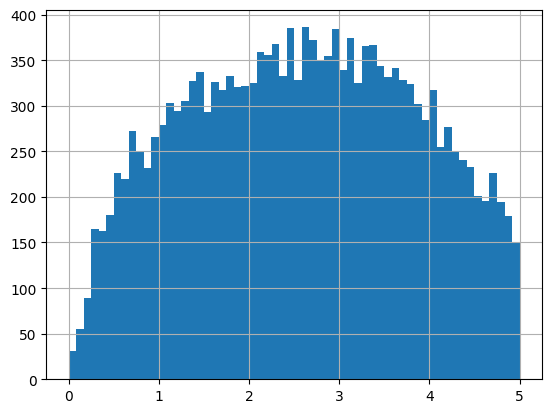

In [13]:
pairs["mahalanobis_dm"].hist(bins=60, range=(0,5))

In [14]:
pairs["chi2Pos_calculated"] = pairs["mahalanobis_dm"]**2
df = pairs.copy()

In [15]:
pairs.head()

,xmm_idx,gaia_idx,sep_arcsec,xmm_SRCID,xmm_SC_POSERR,gaia_Source,pair_id,mahalanobis_dm,dx,dy,sigma_x,sigma_y,dx_norm,dy_norm,chi2Pos_calculated
0,2243,633,3.883303,207628601015020,2.886087,430926300877575168,207628601015020_430926300877575168,1.345535,-3.163144,-2.252729,2.886087,2.886087,-1.095998,-0.780548,1.810465
1,2244,2381,4.100548,207628601010021,2.670601,430935268766538624,207628601010021_430935268766538624,1.535438,4.091767,0.268121,2.670601,2.670601,1.532152,0.100397,2.357570
2,2246,2556,1.223081,207628601010003,2.056250,430935754109847424,207628601010003_430935754109847424,0.594810,1.129392,0.469462,2.056250,2.056250,0.549249,0.228310,0.353799
3,2230,2607,2.163645,207628601015016,2.411271,430935960263857024,207628601015016_430935960263857024,0.897304,-0.470772,2.111807,2.411271,2.411271,-0.195238,0.875807,0.805155
4,2230,2611,5.999037,207628601015016,2.411271,430935960264767360,207628601015016_430935960264767360,2.487897,-3.174353,5.090325,2.411271,2.411271,-1.316465,2.111055,6.189632


In [16]:
df.head()

,xmm_idx,gaia_idx,sep_arcsec,xmm_SRCID,xmm_SC_POSERR,gaia_Source,pair_id,mahalanobis_dm,dx,dy,sigma_x,sigma_y,dx_norm,dy_norm,chi2Pos_calculated
0,2243,633,3.883303,207628601015020,2.886087,430926300877575168,207628601015020_430926300877575168,1.345535,-3.163144,-2.252729,2.886087,2.886087,-1.095998,-0.780548,1.810465
1,2244,2381,4.100548,207628601010021,2.670601,430935268766538624,207628601010021_430935268766538624,1.535438,4.091767,0.268121,2.670601,2.670601,1.532152,0.100397,2.357570
2,2246,2556,1.223081,207628601010003,2.056250,430935754109847424,207628601010003_430935754109847424,0.594810,1.129392,0.469462,2.056250,2.056250,0.549249,0.228310,0.353799
3,2230,2607,2.163645,207628601015016,2.411271,430935960263857024,207628601015016_430935960263857024,0.897304,-0.470772,2.111807,2.411271,2.411271,-0.195238,0.875807,0.805155
4,2230,2611,5.999037,207628601015016,2.411271,430935960264767360,207628601015016_430935960264767360,2.487897,-3.174353,5.090325,2.411271,2.411271,-1.316465,2.111055,6.189632


                mahalanobis_dm  sep_arcsec  xmm_SC_POSERR
mahalanobis_dm        1.000000    0.484529      -0.570603
sep_arcsec            0.484529    1.000000       0.037583
xmm_SC_POSERR        -0.570603    0.037583       1.000000


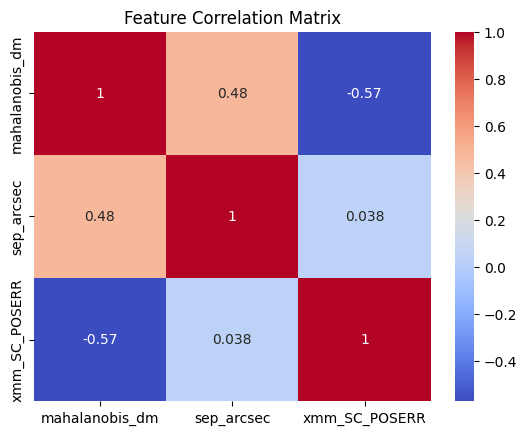

In [17]:
features = df[[
    "mahalanobis_dm",
    "sep_arcsec",
    "xmm_SC_POSERR"
]]
corr = features.corr()
print(corr)
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

In [18]:
arches_df.head(1)

,dMEC,posRA,posDec,ePosA,ePosB,ePosPA,ePosEpoch,chi2Pos,proba_xg,proba_x_g,nPos,xmm_REVOLUT,xmm_OBS_ID_1,xmm_ODF_VERS_1,xmm_RA,xmm_DEC,xmm_PA_PNT_1,xmm_TARGET_1,xmm_MJD_START,xmm_MJD_STOP,xmm_OBS_CLASS,xmm_NDET_1,xmm_NDETGOOD_1,xmm_PN_NEXP_1,xmm_PN_FILT_1,xmm_PN_MODE_1,xmm_PN_TEXP_1,xmm_M1_NEXP_1,xmm_M1_FILT_1,xmm_M1_MODE_1,xmm_M1_TEXP_1,xmm_M2_NEXP_1,xmm_M2_FILT_1,xmm_M2_MODE_1,xmm_M2_TEXP_1,xmm_GAL_LONG_1,xmm_GAL_LAT_1,xmm_frac_1,xmm_gaia_count,xmm_No/Nx,xmm_Clusters,xmm_DETID,xmm_SRCID,xmm_DR3SRCID,xmm_DR3DETID,xmm_DR3DETDIST,xmm_DR3SRCDIST,xmm_DR3MULT,xmm_DR4SRCID,xmm_DR4DETID,xmm_DR4DETDIST,xmm_DR4SRCDIST,xmm_DR4MULT,xmm_IAUNAME,xmm_SRC_NUM,xmm_OBS_ID_2,xmm_REVOLUT_1,xmm_MJD_START_1,xmm_MJD_STOP_1,xmm_OBS_CLASS_1,xmm_PN_FILTER,xmm_M1_FILTER,xmm_M2_FILTER,xmm_PN_SUBMODE,xmm_M1_SUBMODE,xmm_M2_SUBMODE,xmm_RA_1,xmm_DEC_1,xmm_POSERR,xmm_LII,xmm_BII,xmm_RADEC_ERR,xmm_SYSERRCC,xmm_REFCAT,xmm_POSCOROK,xmm_RA_UNC,xmm_DEC_UNC,xmm_CCDPN,xmm_PN_RAWX,xmm_PN_RAWY,xmm_CCDM1,xmm_M1_RAWX,xmm_M1_RAWY,xmm_CCDM2,xmm_M2_RAWX,xmm_M2_RAWY,xmm_EP_1_FLUX,xmm_EP_1_FLUX_ERR,xmm_EP_2_FLUX,xmm_EP_2_FLUX_ERR,xmm_EP_3_FLUX,xmm_EP_3_FLUX_ERR,xmm_EP_4_FLUX,xmm_EP_4_FLUX_ERR,xmm_EP_5_FLUX,xmm_EP_5_FLUX_ERR,xmm_EP_8_FLUX,xmm_EP_8_FLUX_ERR,xmm_EP_9_FLUX,xmm_EP_9_FLUX_ERR,xmm_PN_1_FLUX,xmm_PN_1_FLUX_ERR,xmm_PN_2_FLUX,xmm_PN_2_FLUX_ERR,xmm_PN_3_FLUX,xmm_PN_3_FLUX_ERR,xmm_PN_4_FLUX,xmm_PN_4_FLUX_ERR,xmm_PN_5_FLUX,xmm_PN_5_FLUX_ERR,xmm_PN_8_FLUX,xmm_PN_8_FLUX_ERR,xmm_PN_9_FLUX,xmm_PN_9_FLUX_ERR,xmm_EP_8_RATE,xmm_EP_8_RATE_ERR,xmm_EP_9_RATE,xmm_EP_9_RATE_ERR,xmm_PN_1_RATE,xmm_PN_1_RATE_ERR,xmm_PN_2_RATE,xmm_PN_2_RATE_ERR,xmm_PN_3_RATE,xmm_PN_3_RATE_ERR,xmm_PN_4_RATE,xmm_PN_4_RATE_ERR,xmm_PN_5_RATE,xmm_PN_5_RATE_ERR,xmm_PN_8_RATE,xmm_PN_8_RATE_ERR,xmm_PN_9_RATE,xmm_PN_9_RATE_ERR,xmm_EP_8_CTS,xmm_EP_8_CTS_ERR,xmm_PN_8_CTS,xmm_PN_8_CTS_ERR,xmm_M1_8_CTS,xmm_M1_8_CTS_ERR,xmm_M2_8_CTS,xmm_M2_8_CTS_ERR,xmm_EP_8_DET_ML,xmm_EP_9_DET_ML,xmm_PN_1_DET_ML,xmm_PN_2_DET_ML,xmm_PN_3_DET_ML,xmm_PN_4_DET_ML,xmm_PN_5_DET_ML,xmm_PN_8_DET_ML,xmm_PN_9_DET_ML,xmm_EP_EXTENT,xmm_EP_EXTENT_ERR,xmm_EP_EXTENT_ML,xmm_EP_HR1,xmm_EP_HR1_ERR,xmm_EP_HR2,xmm_EP_HR2_ERR,xmm_EP_HR3,xmm_EP_HR3_ERR,xmm_EP_HR4,xmm_EP_HR4_ERR,xmm_PN_HR1,xmm_PN_HR1_ERR,xmm_PN_HR2,xmm_PN_HR2_ERR,xmm_PN_HR3,xmm_PN_HR3_ERR,xmm_PN_HR4,xmm_PN_HR4_ERR,xmm_PN_1_EXP,xmm_PN_2_EXP,xmm_PN_3_EXP,xmm_PN_4_EXP,xmm_PN_5_EXP,xmm_PN_1_BG,xmm_PN_2_BG,xmm_PN_3_BG,xmm_PN_4_BG,xmm_PN_5_BG,xmm_PN_PILEUP,xmm_M1_PILEUP,xmm_M2_PILEUP,xmm_PN_1_VIG,xmm_PN_2_VIG,xmm_PN_3_VIG,xmm_PN_4_VIG,xmm_PN_5_VIG,xmm_PN_ONTIME,xmm_M1_ONTIME,xmm_M2_ONTIME,xmm_EP_ONTIME,xmm_PN_OFFAX,xmm_M1_OFFAX,xmm_M2_OFFAX,xmm_EP_OFFAX,xmm_PN_MASKFRAC,xmm_M1_MASKFRAC,xmm_M2_MASKFRAC,xmm_DIST_NN,xmm_SUM_FLAG,xmm_EP_FLAG,xmm_PN_FLAG,xmm_M1_FLAG,xmm_M2_FLAG,xmm_TSERIES,xmm_SPECTRA,xmm_EP_CHI2PROB,xmm_PN_CHI2PROB,xmm_M1_CHI2PROB,xmm_M2_CHI2PROB,xmm_PN_FVAR,xmm_PN_FVARERR,xmm_M1_FVAR,xmm_M1_FVARERR,xmm_M2_FVAR,xmm_M2_FVARERR,xmm_VAR_FLAG,xmm_VAR_EXP_ID,xmm_VAR_INST_ID,xmm_SC_RA,xmm_SC_DEC,xmm_SC_POSERR,xmm_SC_DET_ML,xmm_SC_EP_1_FLUX,xmm_SC_EP_1_FLUX_ERR,xmm_SC_EP_2_FLUX,xmm_SC_EP_2_FLUX_ERR,xmm_SC_EP_3_FLUX,xmm_SC_EP_3_FLUX_ERR,xmm_SC_EP_4_FLUX,xmm_SC_EP_4_FLUX_ERR,xmm_SC_EP_5_FLUX,xmm_SC_EP_5_FLUX_ERR,xmm_SC_EP_8_FLUX,xmm_SC_EP_8_FLUX_ERR,xmm_SC_EP_9_FLUX,xmm_SC_EP_9_FLUX_ERR,xmm_SC_HR1,xmm_SC_HR1_ERR,xmm_SC_HR2,xmm_SC_HR2_ERR,xmm_SC_HR3,xmm_SC_HR3_ERR,xmm_SC_HR4,xmm_SC_HR4_ERR,xmm_SC_EXTENT,xmm_SC_EXT_ERR,xmm_SC_EXT_ML,xmm_SC_CHI2PROB,xmm_SC_FVAR,xmm_SC_FVARERR,xmm_SC_VAR_FLAG,xmm_SC_SUM_FLAG,xmm_SC_EP_8_FMIN,xmm_SC_EP_8_FMIN_ERR,xmm_SC_EP_8_FMAX,xmm_SC_EP_8_FMAX_ERR,xmm_MJD_FIRST,xmm_MJD_LAST,xmm_N_DETECTIONS,xmm_CONFUSED,xmm_HIGH_BACKGROUND,xmm_ODF_VERS_2,xmm_PA_PNT_2,xmm_TARGET_2,xmm_NDET_2,xmm_NDETGOOD_2,xmm_PN_NEXP_2,xmm_PN_FILT_2,xmm_PN_MODE_2,xmm_PN_TEXP_2,xmm_M1_NEXP_2,xmm_M1_FILT_2,xmm_M1_MODE_2,xmm_M1_TEXP_2,xmm_M2_NEXP_2,xmm_M2_FILT_2,xmm_M2_MODE_2,xmm_M2_TEXP_2,xmm_GAL_LONG_2,xmm_GAL_LAT_2,xmm_frac_2,xmm_GroupID,xmm_GroupSize,gaia_Source,gaia_DR3Name,gaia_RA_ICRS,gai

### Ground Truth Prep

In [19]:
arches_df["pair_id"] = (
    arches_df["xmm_SRCID"].astype(str) + "_" +
    arches_df["gaia_Source"].astype(str)
)

pairs["label"] = pairs["pair_id"].isin(arches_df["pair_id"]).astype(int)
pairs["label"].value_counts()
# pairs.groupby("xmm_idx")["label"].sum().value_counts()

label
0    14935
1     7716
Name: count, dtype: int64

In [20]:
pairs["xmm_idx"].nunique()
pairs.groupby("xmm_idx")["label"].sum().describe()

count    5602.000000
mean        1.377365
std         1.324932
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        14.000000
Name: label, dtype: float64

In [21]:
len(set(pairs["pair_id"]) & set(arches_df["pair_id"]))

7716

In [22]:
features = [
    "dx_norm",
    "dy_norm",
    "mahalanobis_dm",
    "sep_arcsec",
    "xmm_SC_POSERR"
]

X = pairs[features].values
y = pairs["label"].values
groups = pairs["xmm_idx"].values

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced"
)

model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300)

In [24]:
pairs["pred_prob"] = model.predict_proba(X)[:,1]

In [25]:
best_matches = pairs.loc[
    pairs.groupby("xmm_idx")["pred_prob"].idxmax()
]

In [26]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y, pairs["pred_prob"])
best_matches["correct"] = best_matches["label"]

accuracy = best_matches["correct"].mean()
print("Counterpart recovery accuracy:", accuracy)


Counterpart recovery accuracy: 0.7665119600142806


In [27]:
# from sklearn.metrics import (
#     roc_auc_score,
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score,
#     confusion_matrix,
#     classification_report
# )

# # Probabilities
# y_prob = pairs["pred_prob"]

# # Convert to predicted class
# y_pred = (y_prob >= 0.5).astype(int)

# # Metrics
# roc = roc_auc_score(y, y_prob)
# acc = accuracy_score(y, y_pred)
# precision = precision_score(y, y_pred)
# recall = recall_score(y, y_pred)
# f1 = f1_score(y, y_pred)

# print("ROC-AUC:", roc)
# print("Accuracy:", acc)
# print("Precision:", precision)
# print("Recall:", recall)
# print("F1-score:", f1)

# # Confusion matrix
# print("\nConfusion Matrix:")
# print(confusion_matrix(y, y_pred))

# # Full classification report
# print("\nClassification Report:")
# print(classification_report(y, y_pred))

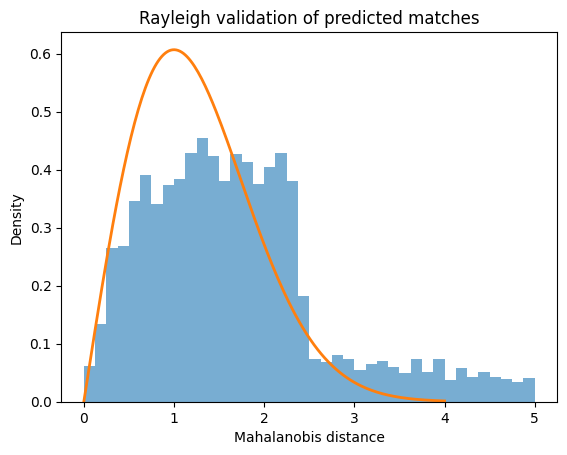

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rayleigh

dm = best_matches["mahalanobis_dm"]

x = np.linspace(0,4,200)

plt.hist(dm, bins=40, density=True, alpha=0.6, range=(0,5))
plt.plot(x, rayleigh.pdf(x), linewidth=2)

plt.xlabel("Mahalanobis distance")
plt.ylabel("Density")
plt.title("Rayleigh validation of predicted matches")
plt.show()

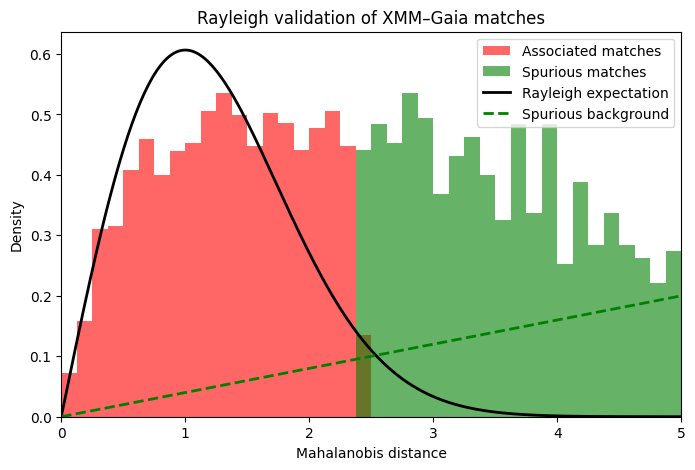

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rayleigh

# split matches
associated = best_matches[best_matches["label"] == 1]["mahalanobis_dm"]
spurious = best_matches[best_matches["label"] == 0]["mahalanobis_dm"]

# axis range
xmin = 0
xmax = 5   # change to 15 if desired

x = np.linspace(xmin, xmax, 300)

plt.figure(figsize=(8,5))

# histograms
plt.hist(associated, bins=40, range=(xmin,xmax),
         density=True, alpha=0.6, color="red",
         label="Associated matches")

plt.hist(spurious, bins=40, range=(xmin,xmax),
         density=True, alpha=0.6, color="green",
         label="Spurious matches")

# Rayleigh curve (true positional matches)
plt.plot(x, rayleigh.pdf(x, scale=1),
         color="black", linewidth=2,
         label="Rayleigh expectation")

# Poisson-like background approximation
# random matches scale roughly ∝ r in radial space
background = x / xmax**2
plt.plot(x, background,
         linestyle="--",
         color="green",
         linewidth=2,
         label="Spurious background")

plt.xlim(xmin, xmax)

plt.xlabel("Mahalanobis distance")
plt.ylabel("Density")
plt.title("Rayleigh validation of XMM–Gaia matches")
plt.legend()

plt.show()

Rayleigh sigma estimate: 1.0518203075935917


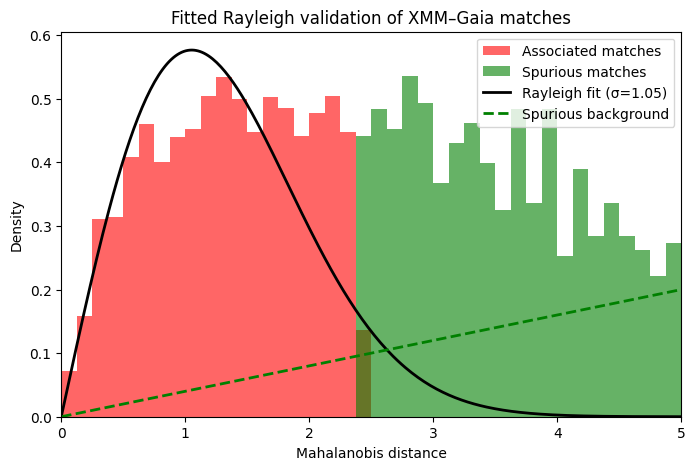

In [30]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import rayleigh

# split matches
associated = best_matches[best_matches["label"] == 1]["mahalanobis_dm"]
spurious = best_matches[best_matches["label"] == 0]["mahalanobis_dm"]

# axis range
xmin = 0
xmax = 5
x = np.linspace(xmin, xmax, 300)

# --- Rayleigh scale estimation ---
sigma = np.sqrt((associated**2).mean() / 2)
rayleigh_fit = rayleigh.pdf(x, scale=sigma)

plt.figure(figsize=(8,5))

# histograms
plt.hist(associated, bins=40, range=(xmin,xmax),
         density=True, alpha=0.6, color="red",
         label="Associated matches")

plt.hist(spurious, bins=40, range=(xmin,xmax),
         density=True, alpha=0.6, color="green",
         label="Spurious matches")

# fitted Rayleigh curve
plt.plot(x, rayleigh_fit,
         color="black",
         linewidth=2,
         label=f"Rayleigh fit (σ={sigma:.2f})")

# spurious background
background = x / xmax**2
plt.plot(x, background,
         linestyle="--",
         color="green",
         linewidth=2,
         label="Spurious background")

plt.xlim(xmin, xmax)

plt.xlabel("Mahalanobis distance")
plt.ylabel("Density")
plt.title("Fitted Rayleigh validation of XMM–Gaia matches")
plt.legend()

print("Rayleigh sigma estimate:", sigma)

plt.show()